In [1]:
from braindecode.datautil import load_concat_dataset
from braindecode.preprocessing import create_fixed_length_windows
import mne
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import torch
from scipy.signal import find_peaks
import pickle

# Windows Extraction

In [ ]:
savedir='/space/gzanardini/tuh_eeg/preprocessed/full/'
data=load_concat_dataset(path=savedir, preload=True)

In [ ]:
win_time=10
win_lenght=int(250*win_time)
overlap=0.5
win_stride=int(win_lenght*overlap)
data_wins= create_fixed_length_windows(data, start_offset_samples=0, stop_offset_samples=None, window_size_samples=win_lenght, window_stride_samples=win_stride, drop_last_window=True)

In [ ]:
#check samples with calibration signal at the beginning
idxs=[]
for i in range(len(data.datasets)):
    if not np.all(data.datasets[i].raw.get_data()[19] == 0) and data.datasets[i].raw.get_data()[19][0] != 0:
        idxs.append(i)
        #events = mne.find_events(data.datasets[i].raw, uint_cast=True, min_duration=2/data.datasets[i].raw.info['sfreq'], output = 'step', consecutive=True)
        plt.figure(figsize=(20,3))
        plt.plot(data.datasets[i].raw.get_data()[19])
        #if events is not None:
        #    for event in events:
        #        event[0] = event[0]/data.datasets[i].raw.info['sfreq']
        #        plt.axvline(x=event[0], color='r')
        plt.show()
        print('CHLEN',len(data.datasets[i].raw.get_data()[19]))
        #print(events)

In [ ]:
from torch.utils.data import DataLoader

batch_size=1
dl=DataLoader(data_wins, batch_size=batch_size, shuffle=False, num_workers=2)


# if 20th channel of sample is not zeroes, append the first 19 channels to x and the target to y
X=[]
Y=[]
pat_list=[]
samp_n=-1
n_peaks=[]
peaks_list=[]

for i, (x, y, _) in enumerate(dl):
    if _[0]==0:
        samp_n+=1
    if not torch.all(x[0][19] == 0) and x[0][19][0] == 0:
        X.append(x[0].numpy())
        Y.append(y.numpy())
        pat_list.append(data.description['subject'][samp_n])
        print(i)

        #find peaks on the 20th channel
        peaks, _ = find_peaks(-x[0][19].numpy())
        
        peaks_list.append(peaks)
        n_peaks.append(len(peaks))

        '''plt.figure(figsize=(20,3))
        plt.plot(x[0][19].numpy())
        plt.plot(peaks, x[0][19][peaks], "x")
        plt.show()'''

In [ ]:
print(Y), print(pat_list), print(n_peaks)

Y_arr=np.array(Y)
pat_arr=np.array(pat_list)
X=np.array(X)

print(Y_arr.shape), print(pat_arr.shape), print(X.shape)

labels_with_pats_array = np.column_stack((Y_arr, pat_arr))
print(labels_with_pats_array)

# save the data
np.save('labels_with_pats.npy', labels_with_pats_array)
np.save('X.npy', X)
np.save('n_peaks.npy', n_peaks)

with open('peaks_list.pkl', 'wb') as f:
    pickle.dump(peaks_list, f)


In [ ]:
# find the indices of the samples where the number of peaks is greater than 80

lotsapeaks = [i for i, n in enumerate(n_peaks) if n>80]

# Art rej - Montage

In [24]:
def buffer_data(data, sample_rate):
    """
    Buffers the data into segments of 1 second each, with padding if necessary.
    """
    buffer_len = sample_rate
    num_segments = np.ceil(len(data) / buffer_len).astype(int)
    padded_len = num_segments * buffer_len
    padded_data = np.zeros(padded_len)
    padded_data[:len(data)] = data
    return padded_data.reshape(num_segments, buffer_len)

def artifact_rejection(data, sample_rate, artifact_rejection_width):
    num_channels, num_samples = data.shape

    expected_samples = np.ceil(num_samples / sample_rate).astype(int) * sample_rate
    data_ar = np.zeros((num_channels, expected_samples))  # padding
    
    for pp in range(num_channels):
        A2 = data[pp, :]
        A3 = buffer_data(A2, sample_rate) # buffer into 1-second segments with padding
        rms_Val = np.sqrt(np.mean(A3**2, axis=1))
        threshold = artifact_rejection_width * np.std(rms_Val) + np.median(rms_Val)
        noise_index = rms_Val < threshold
        A3[~noise_index, :] = 0 # replace the noise segments with zeros
        data_ar[pp, :] = A3.flatten()
    return data_ar

In [25]:
channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
            'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']

# Visual

In [ ]:
X=np.load('X.npy')
print('X:',X.shape)
labels_with_pats_array=np.load('labels_with_pats.npy')
print('labels:',labels_with_pats_array.shape)

Y=labels_with_pats_array[:,0].astype(int)
pat_list=labels_with_pats_array[:,1]

n_peaks=np.load('n_peaks.npy')
peaks_list = pickle.load(open('peaks_list.pkl', 'rb'))

X_clean=np.zeros_like(X)
for i in range(X.shape[0]):
    X_clean[i][:19] = artifact_rejection(X[i], 250, 3)[:19]
    X_clean[i][:19] = X_clean[i][:19]-np.mean(X_clean[i], axis=0, keepdims=True)
    X_clean[i][19] = X[i][19]

X: (1719, 20, 2500)
labels: (1719, 2)


In [5]:
lotsapeaks = [i for i, n in enumerate(n_peaks) if n>90]

# plot only FP1, FP2, O1, O2, T5, T6, PZ and PHOTIC PH
chs = [0, 11, 7, 18, 6, 17, 10, 19]

idxs_with_epilepsy = [i for i, y in enumerate(Y) if y==1]

#check which samples with a lot of peaks have epilepsy
for i in idxs_with_epilepsy:
    if i  not in lotsapeaks:
    #pop the idx from the list
        idxs_with_epilepsy.pop(idxs_with_epilepsy.index(i))

idxs_healty = [i for i, y in enumerate(Y) if y==0]
for i in idxs_healty:
    if i  not in lotsapeaks:
    #pop the idx from the list
        idxs_healty.pop(idxs_healty.index(i))

In [6]:
#compute stft of each channel
from scipy.signal import stft

spectrograms=[]

win_lenght=128
overlap=0.5
win_stride=int(win_lenght*overlap)

for i in range(X_clean.shape[0]):
    f, t, Zxx = stft(X_clean[i], fs=250, nperseg=win_lenght, noverlap=win_stride, nfft=2048, scaling='psd')
    spectrograms.append(abs(Zxx)**2)
spectrograms=np.array(spectrograms)

spectrograms_scaled = np.zeros_like(spectrograms, dtype=np.float64)

for i in range(spectrograms.shape[0]):
    for j in range(spectrograms.shape[1]):
        spectrograms_scaled[i][j] = 20*np.log10(np.abs(spectrograms[i][j])/np.max(np.abs(spectrograms[i][j])))
        
print(spectrograms_scaled.dtype)

/tmp/ipykernel_3595266/1405022857.py:19: RuntimeWarning: divide by zero encountered in log10
  spectrograms_scaled[i][j] = 20*np.log10(np.abs(spectrograms[i][j])/np.max(np.abs(spectrograms[i][j])))


float64


In [7]:
def plot_data(idx, llim):
    tt=np.linspace(0, 10, 2500)

    plt.figure(figsize=(15,15))
    for i in range(8):
        plt.subplot(8,1,i+1)
        plt.plot(tt,X[idx][chs[i]], label='raw')
        plt.plot(tt,X_clean[idx][chs[i]], label='CAR', scaley=False)
        plt.title(channels[chs[i]])
        plt.suptitle('Patient: '+pat_list[idx]+' - Epilepsy: '+str(Y[idx]))
        plt.legend()
        plt.xticks(np.arange(0, 10.1, 1))
    plt.show()

#pliot only frequencies up to 50 Hz
    flim=300

    plt.figure(figsize=(15,15))
    for j in range(7):
        plt.subplot(8,1,j+1)
        plt.pcolormesh(t, f[:flim], spectrograms_scaled[idx][chs[j]][:flim], shading='gouraud')
        plt.title(channels[chs[j]])
        plt.suptitle('Patient: '+pat_list[idx]+' - Epilepsy: '+str(Y[idx]))
        if j==6:
            plt.colorbar(location='bottom')
        plt.clim(llim, 0)
        
    plt.show()


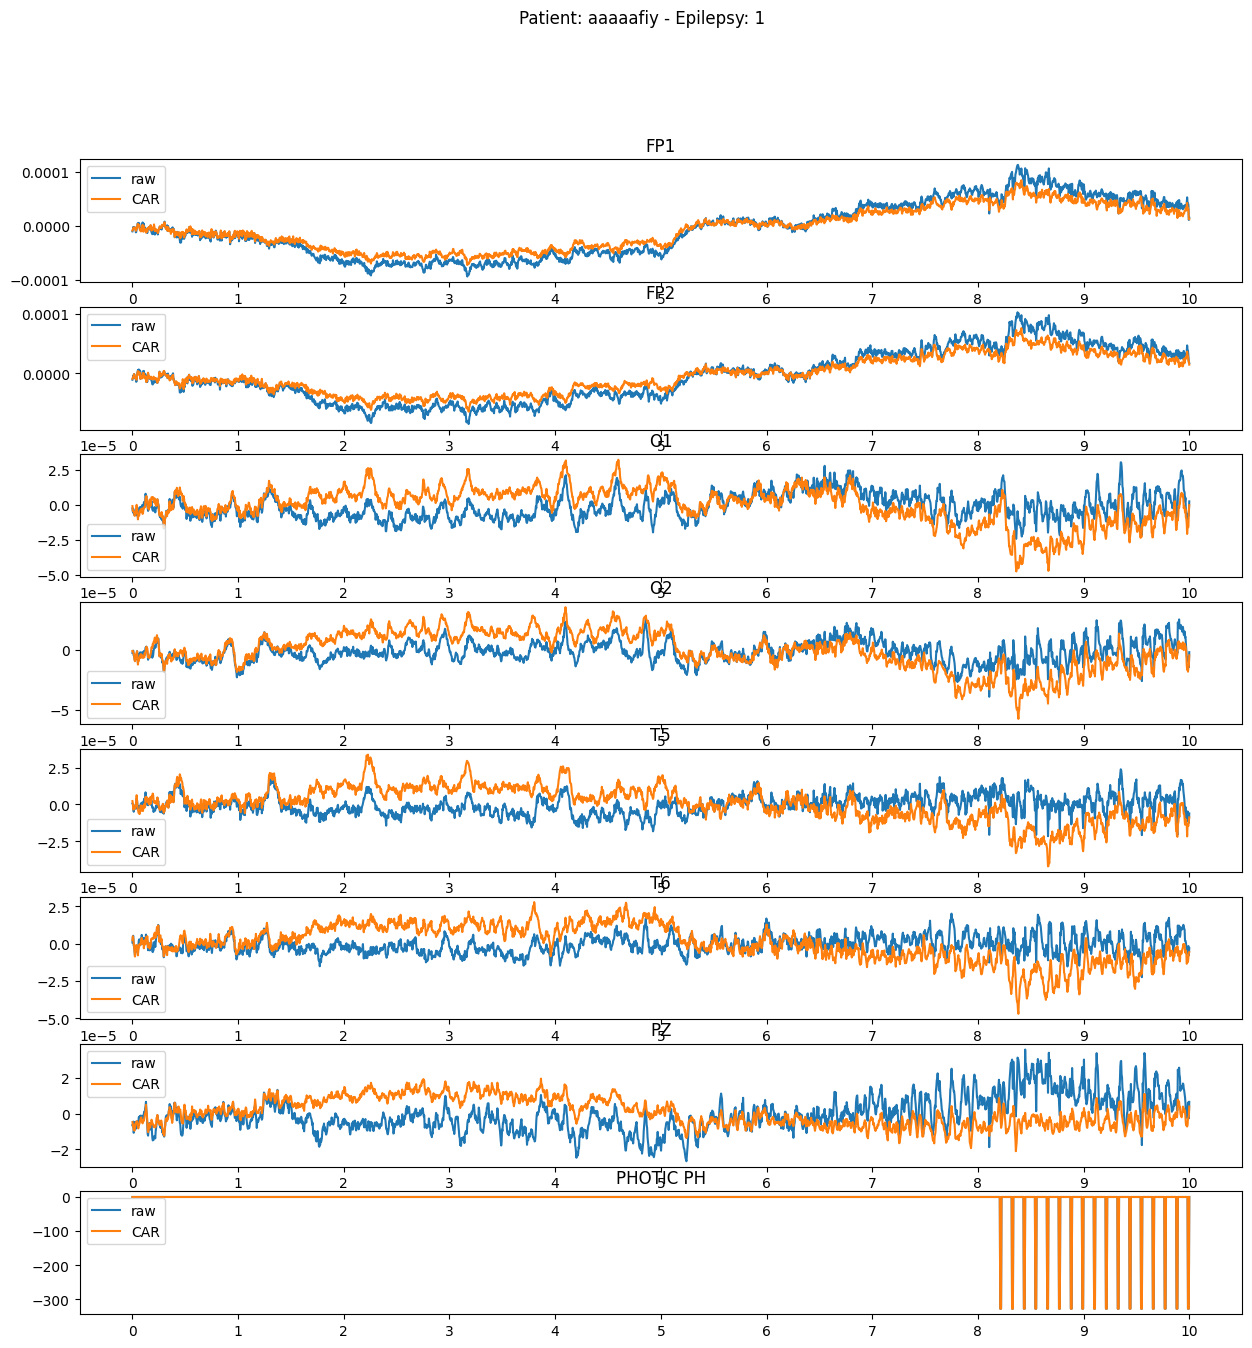

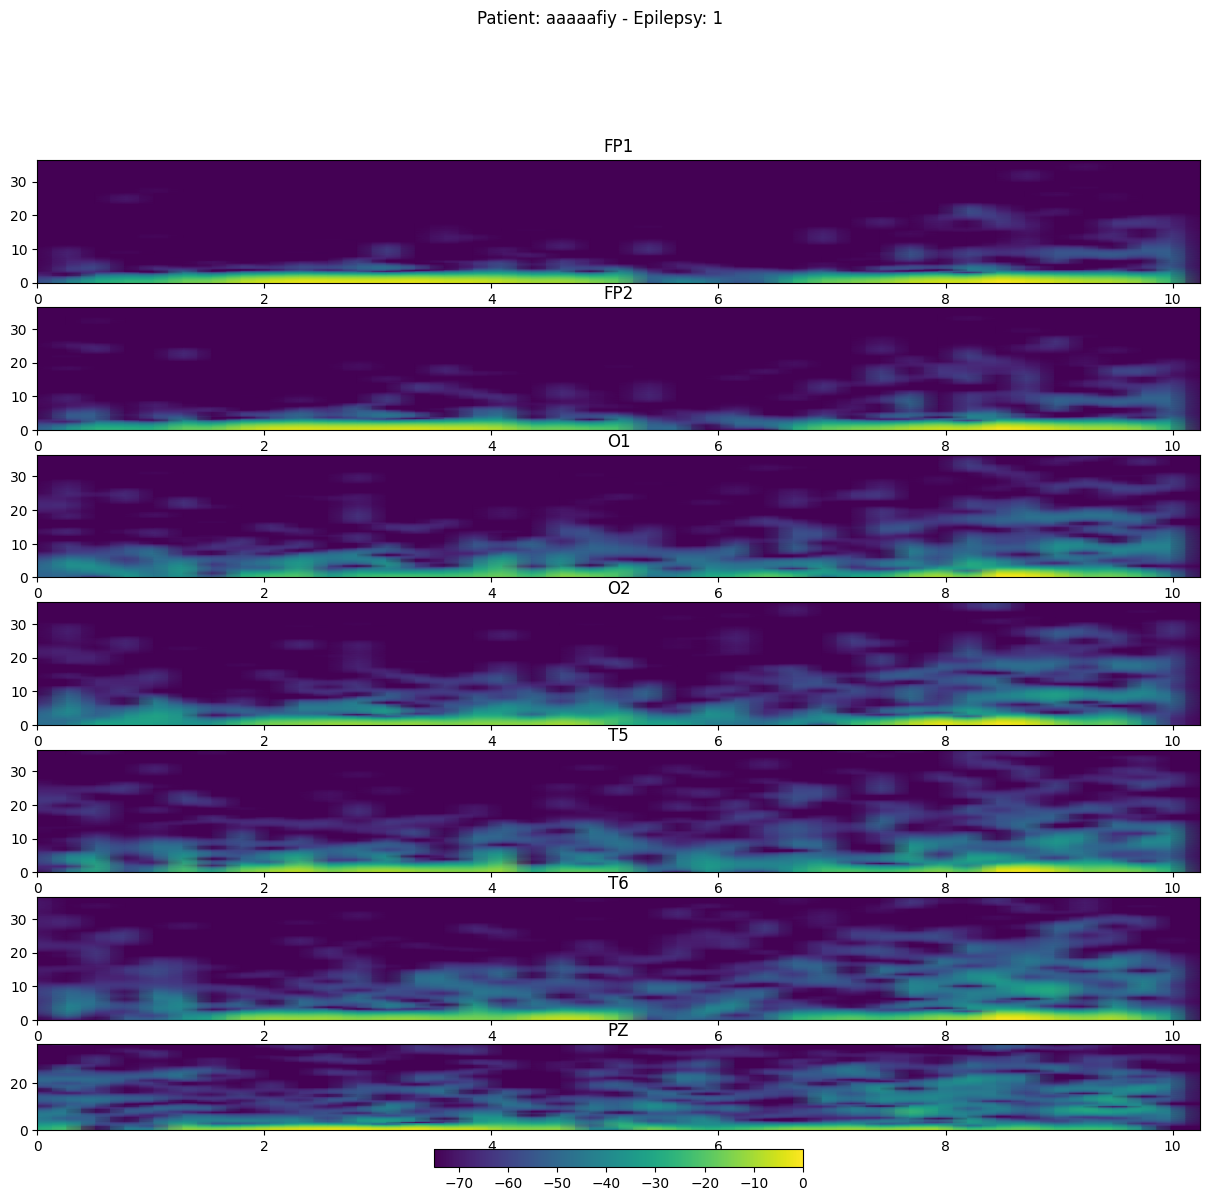

In [27]:
plot_data(idxs_with_epilepsy[31],-75)


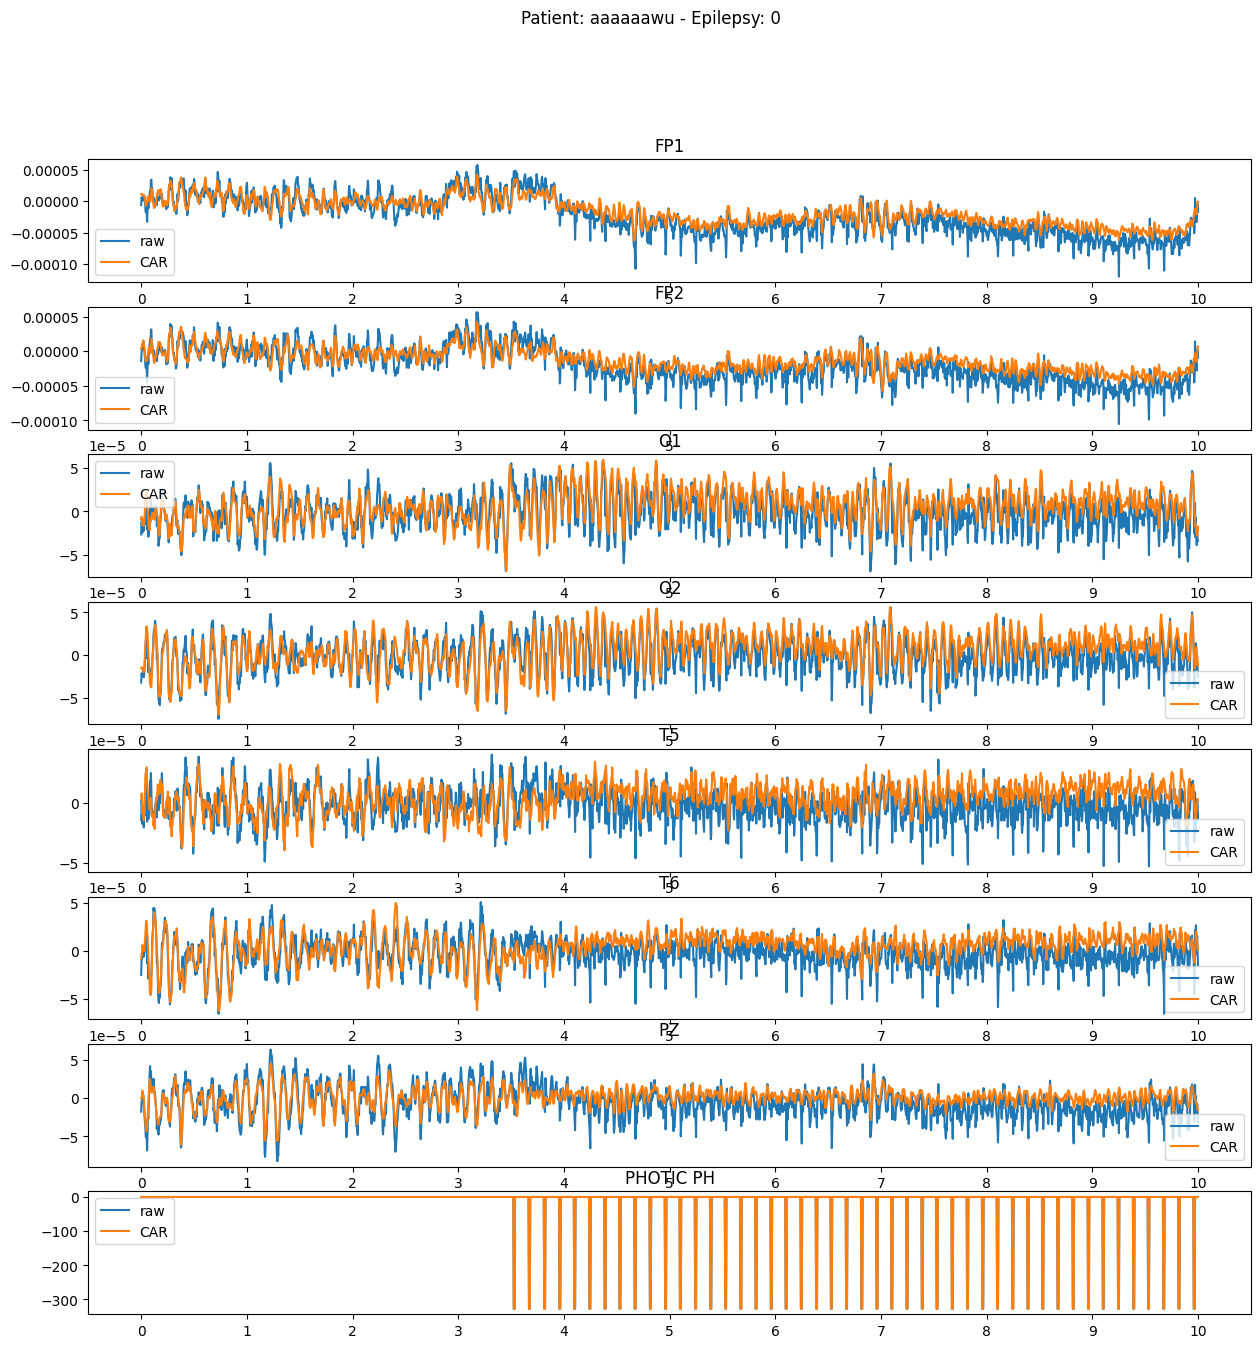

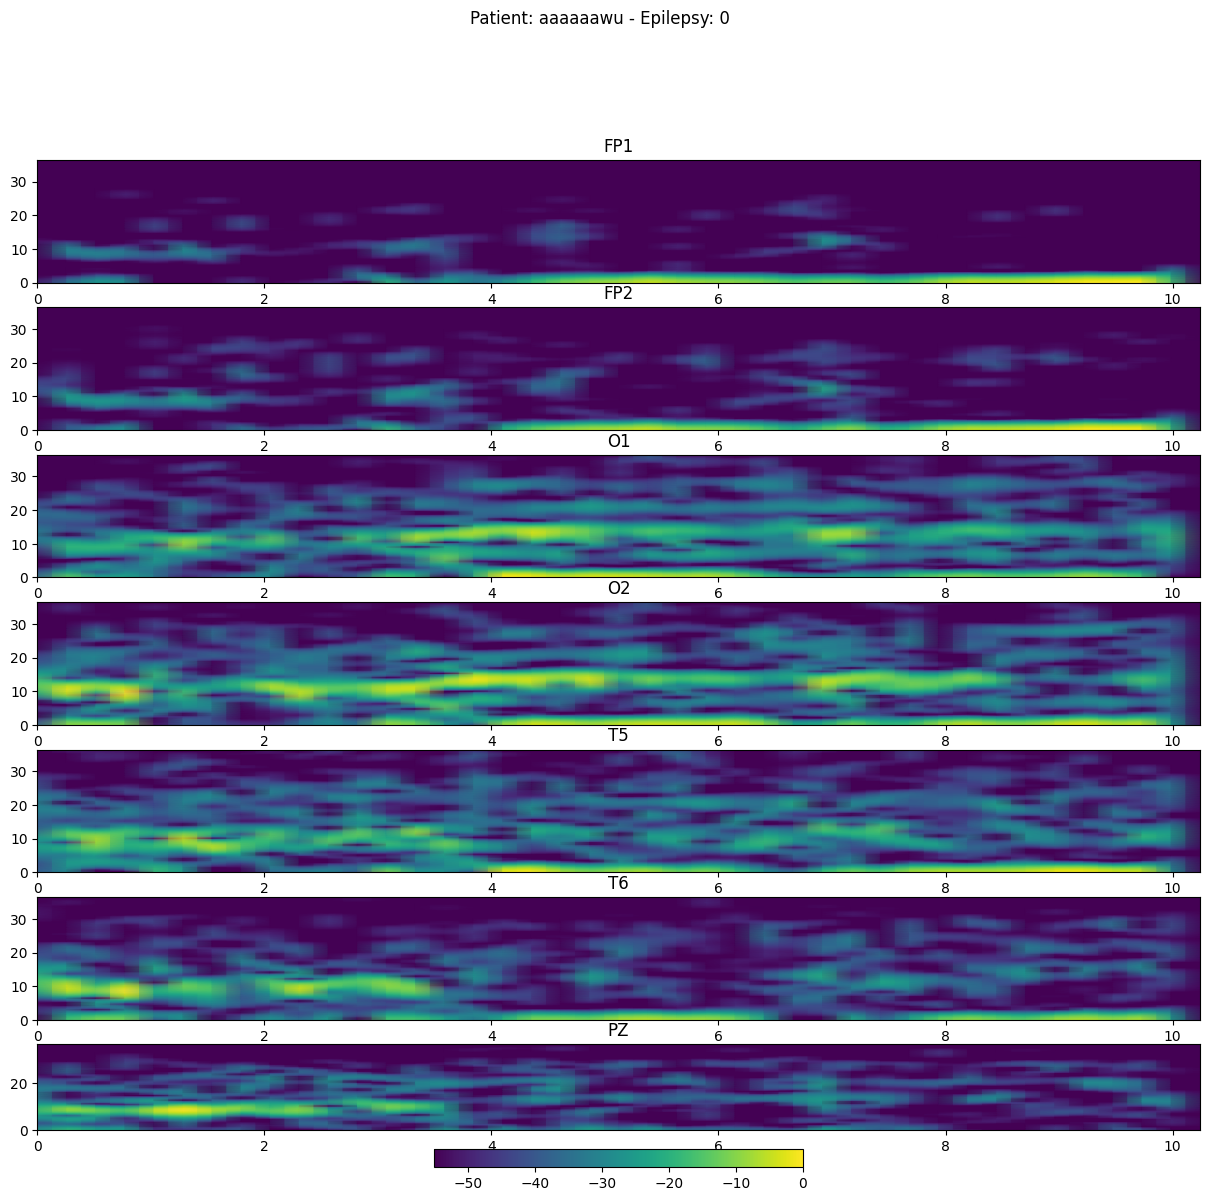

In [15]:
plot_data(idxs_healty[32],-55)
#31 weird alpha after photostimulation